In [1]:
import pandas as pd
import numpy as np
import math

In [2]:
data = pd.read_csv("\\Users\\Dell\\Downloads\\moonDataset.csv")
data

,X1,X2,X3,label
0,-0.926767,-0.111073,0.086017,0
1,-0.917583,0.706006,0.058041,0
2,0.437984,0.899093,0.072543,0
3,0.089694,0.291446,0.070444,1
4,0.110672,-0.070806,-0.090376,1
...,...,...,...,...
195,-0.540630,0.901834,-0.058539,0
196,0.032085,0.411465,-0.064823,1
197,0.691922,0.679103,0.020613,0
198,0.017034,0.930984,-0.034133,0


In [3]:
#input # بشكل مختصر، الكود يقوم بإنشاء مصفوفة جديدة من نوع NumPy بنفس حجم مصفوفة البيانات الأصلية ويقوم بنسخ البيانات من المصفوفة الأصلية إلى الجديدة صفًا بصف.
inputs = np.empty((data.shape[0] , data.shape[1]))
for i in range(data.shape[0]):
  inputs[i] = data.iloc[i]

In [4]:
def sigmoid(input):
  return(1 / (1+math.pow(math.e,-input)))

In [5]:
def der_sigmoid(input):
  return(sigmoid(input)*(1-sigmoid(input)))

In [6]:
def sq_error(i,output):
  return(math.pow((inputs[i][3]-output),2))

In [7]:
def der_sq_error(i,output):
  return((-2*(inputs[i][3]-output)))

In [ ]:


#weights for headden layer
weights_headden_layer = np.array([-0.3, -0.2])

#biases
biases = np.array([-0.4, 0.2, 0.1])

epochs = int(input("enter number of epochs you want to apply : "))
learnning_rate = float(input('enter learnning rate you want to use : '))
MSE_train = []
for epoch in range(epochs):
  MSE = np.empty(len(inputs))
  for i in range(inputs.shape[0]):
    #Forward pass

    #h1
    input_h1 = np.dot(inputs[i, 0:3],weights[0])+biases[0]
    output_h1 = sigmoid(input_h1)

    #h2
    input_h2 = np.dot(inputs[i, 0:3],weights[1])+biases[1]
    output_h2 = sigmoid(input_h2)

    #o1
    output_headden = np.array([output_h1,output_h2])
    input_o1 = np.dot(output_headden,weights_headden_layer)+biases[2]
    output = sigmoid(input_o1)

    #Error
    square_error = sq_error(i,output)
    MSE[i] = square_error

    #backward pass تحديث الأوزان والانحيازات باستخدام عملية الانتشار العكسي (Backpropagation)، حيث تُحسب مشتقات مربع الخطأ بالنسبة للوزن والانحياز، ويتم تحديثها وفقاً لمعدل التعلم.


    weights[0] = weights[0] - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)*weights_headden_layer[0]*der_sigmoid(input_h1)*inputs[i,0:3]))
    weights[1] = weights[1] - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)*weights_headden_layer[1]*der_sigmoid(input_h2)*inputs[i,0:3]))

    biases[0] = biases[0] - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)*weights_headden_layer[0]*der_sigmoid(input_h1)))
    biases[1] = biases[1] - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)*weights_headden_layer[1]*der_sigmoid(input_h2)))
    biases[2] = biases[2] - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)))

    weights_headden_layer = weights_headden_layer - (learnning_rate*(der_sq_error(i,output)*der_sigmoid(input_o1)*output_headden))

  MSE_train.append(MSE.mean())

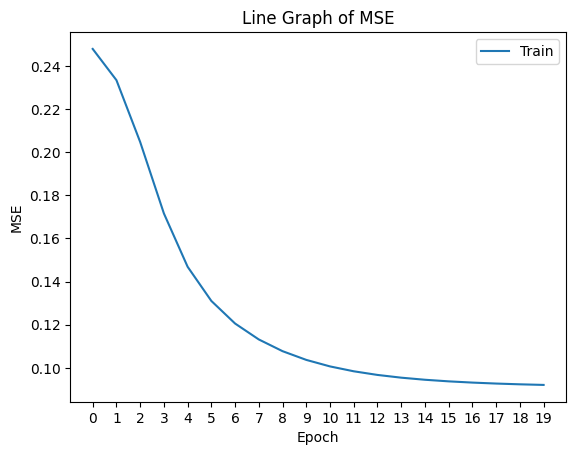

In [ ]:
import matplotlib.pyplot as plt

# Create x-axis values (assuming each element is a data point)
x = range(len(MSE_train))

# Plotting the array as a line graph
plt.plot(x, MSE_train, label='Train')

plt.xticks(np.arange(0,len(MSE_train),1))

# Adding labels and title
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Line Graph of MSE')

plt.legend()

# Display the graph
plt.show()